# Fitted scores, asymptotic expansion, and scaled bias

This notebook asks whether the fitted-score condition, the two expansion remainders,
and the **root-$n$-scaled signed bias** become small as sample size increases.
It also compares the original Adam protocol with additional full-batch optimization
on the **same data and starting fit**.

Your original `run/` results are read below without alteration. The previous executed
notebook is preserved as `psi_n_diagnostic_before_expansion_v2.ipynb`.
New runs use a separate configuration- and code-specific `run_expansion_v2/` folder.

**Current configuration:** `RUN_EXPERIMENT = True`, `PROFILE = "main"`.
Run All starts the reduced-cost main simulation: **50 replications at each of four sample sizes,
300 baseline epochs, and 500 polishing epochs**. Set `RUN_EXPERIMENT = False` to analyze saved
results only. Increase replications to resolve small biases. These notebook overrides leave
the helper module's preset definitions unchanged.
Computational functions are in [diagnostic_helpers.py](diagnostic_helpers.py).


## The bias question

The requested target is

$$
b_n=\sqrt n\,E[\hat\theta-\theta_0]\longrightarrow0.
$$

With $B$ independent Monte Carlo replications, estimate it by

$$
\hat b_n=\frac1B\sum_{b=1}^B\sqrt n(\hat\theta_b-\theta_0),\qquad
\widehat{\mathrm{SE}}(\hat b_n)=
\frac{\mathrm{SD}_b[\sqrt n(\hat\theta_b-\theta_0)]}{\sqrt B}.
$$

The tables and plots include Student-$t$ 95% Monte Carlo intervals. These describe uncertainty
in **the estimated bias**, not confidence intervals for $\theta_0$ in one dataset.
An interval containing zero is not evidence that the bias is negligible. The plot includes
a configurable practical tolerance; an interval wholly inside that band gives stronger
finite-sample evidence of small bias, but still does not prove a limit.

By contrast, $\sqrt nE|\hat\theta-\theta_0|$, $\sqrt{nE(\hat\theta-\theta_0)^2}$,
and the SD of $\sqrt n(\hat\theta-\theta_0)$ generally have **nonzero** limits.
They are reported as calibration measures, not vanishing targets.
Convergence in distribution to a centered normal alone does not imply $b_n\to0$;
convergence of means additionally needs moment control, such as uniform integrability.


In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

# Locate this experiment from either the repository root or the notebook directory.
BASE = None
for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    for candidate in [parent, parent / "results" / "2026-09-23_psi_n_thm33"]:
        if (candidate / "diagnostic_helpers.py").exists():
            BASE = candidate
            break
    if BASE is not None:
        break
if BASE is None:
    raise FileNotFoundError("Open the notebook from its folder or the dplqr repository")
if str(BASE) not in sys.path:
    sys.path.insert(0, str(BASE))
import diagnostic_helpers as diag
diag = importlib.reload(diag)
pd.set_option("display.max_columns", 20)
print("Experiment:", BASE)
print(f"J = {diag.J:.8f}; Gaussian-model root-n SD benchmark = {diag.ASYMPTOTIC_SD:.6f}")


Experiment: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-23_psi_n_thm33
J = 0.09973557; Gaussian-model root-n SD benchmark = 2.506628


In [2]:
RUN_EXPERIMENT = True
PROFILE = "main"       # "smoke", "pilot", or "main"
WIDTH_MODE = "fixed"    # "growing" is an exploratory network-size comparison
CONFIG = diag.make_config(PROFILE, WIDTH_MODE)

# Reduced-cost main run: Q is the number of replications per sample size.
Q = 50
if PROFILE == "main":
    CONFIG.update(reps=Q, baseline_epochs=300, polish_epochs=500)
# Keep n = [500, 1000, 2000, 4000] and the original integration accuracy.
# This is useful for broad trends; small scaled biases need more replications.

# Editable examples (edit before running):
# CONFIG["reps"] = 100  # optional: more precise Monte Carlo estimates
# CONFIG["n_values"] = [500, 1000, 2000, 4000, 8000]
# CONFIG["polish_epochs"] = 1500
# CONFIG["integration_power"] = 14  # points per scramble = 2**power
diag.validate_config(CONFIG)
display(pd.Series(CONFIG, name="value").to_frame())
RUN_DIR = diag.run_directory(BASE, CONFIG)
print("New run directory:", RUN_DIR)
print("Planned datasets:", len(CONFIG["n_values"]) * CONFIG["reps"])
print("Each dataset has baseline and polished diagnostics; models are saved.")


,value
schema,2
profile,main
n_values,"[500, 1000, 2000, 4000]"
reps,50
baseline_epochs,300
polish_epochs,500
integration_power,13
integration_scrambles,8
width_mode,fixed
hidden,"[16, 16]"


New run directory: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-23_psi_n_thm33\run_expansion_v2\main_26a7078945fc
Planned datasets: 200
Each dataset has baseline and polished diagnostics; models are saved.


## What the existing 30-replication run already says

The old CSV contains $\hat\theta$ and the data-generation seed. Its DGP is validated before
reconstructing the true errors and oracle score. Thus we can recover the scaled signed bias
and the **total linear-expansion residual** without retraining.
The fitted neural functions were not saved, so we cannot retrospectively separate
the empirical-process and Taylor remainders. The old files remain unchanged.


,n,completed_reps,root_n_bias,mc_se,ci_low,ci_high,root_n_sd,root_n_mae,root_n_rmse,oracle_wald_coverage
0,500,30,-1.499814,0.355910,-2.227731,-0.771896,1.949398,1.952954,2.433706,0.966667
1,1000,30,0.772414,0.473187,-0.195362,1.740190,2.591752,2.206785,2.662686,0.966667
2,2000,30,0.714326,0.508535,-0.325746,1.754398,2.785363,2.275833,2.830177,0.966667


,n,term,mean_abs,mc_se,ci_low,ci_high,q90_abs
0,500,S,0.117319,0.013537,0.089633,0.145005,0.264121
1,500,R_score,0.188215,0.024842,0.137408,0.239023,0.350623
2,500,R_theta,1.887142,0.249079,1.377718,2.396566,3.515529
3,500,E_plus_T,0.109580,0.018320,0.072111,0.147050,0.300839
4,500,W,0.244158,0.030590,0.181595,0.306721,0.533403
5,1000,S,0.080656,0.010500,0.059181,0.102131,0.157349
6,1000,R_score,0.095145,0.016817,0.060750,0.129541,0.232808
7,1000,R_theta,0.953975,0.168619,0.609110,1.298840,2.334256
8,1000,E_plus_T,0.082694,0.012806,0.056502,0.108885,0.151249
9,1000,W,0.193447,0.026145,0.139973,0.246920,0.379057


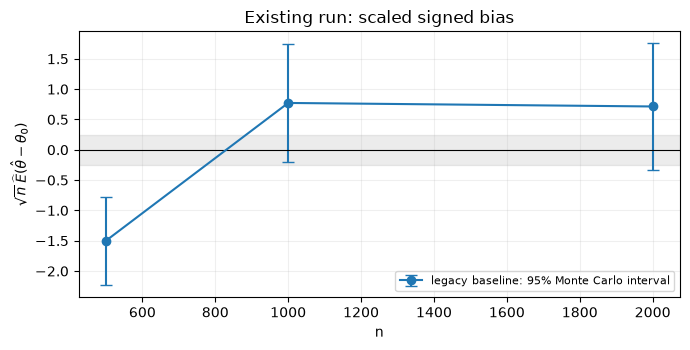

In [3]:
legacy = diag.legacy_diagnostics(BASE)
if legacy.empty:
    print("No legacy run found. New-run cells below are still usable.")
else:
    legacy_bias = diag.bias_summary(legacy)
    display(legacy_bias[["n", "completed_reps", "root_n_bias", "mc_se", "ci_low", "ci_high",
                         "root_n_sd", "root_n_mae", "root_n_rmse", "oracle_wald_coverage"]])
    legacy_terms = []
    for n, group in legacy.groupby("n"):
        for metric in ["S", "R_score", "R_theta", "E_plus_T", "W"]:
            mean, se, low, high = diag.mean_interval(group[metric].abs())
            legacy_terms.append(dict(n=n, term=metric, mean_abs=mean, mc_se=se,
                                     ci_low=max(0, low), ci_high=high,
                                     q90_abs=group[metric].abs().quantile(.9)))
    display(pd.DataFrame(legacy_terms))
    fig, ax = plt.subplots(figsize=(7, 3.6))
    g = legacy_bias.sort_values("n")
    ax.errorbar(g.n, g.root_n_bias, yerr=[g.root_n_bias-g.ci_low, g.ci_high-g.root_n_bias],
                marker="o", capsize=4, label="legacy baseline: 95% Monte Carlo interval")
    ax.axhline(0, color="black", linewidth=.8)
    ax.axhspan(-CONFIG["bias_tolerance"], CONFIG["bias_tolerance"], color="gray", alpha=.15)
    ax.set(xlabel="n", ylabel=r"$\sqrt{n}\,\widehat{E}(\hat\theta-\theta_0)$",
           title="Existing run: scaled signed bias")
    ax.legend(fontsize=8); ax.grid(alpha=.2)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


## Exact decomposition and the vanishing targets

Keep the score normalization

$$
\Psi_n(\zeta,h)=-\frac1n\sum_i
\left[\tau-\mathbf1\{\epsilon_i-\zeta\tilde X_i-h(Z_i)<0\}\right]\tilde X_i,
\qquad \tilde X=X-\varphi^*(Z).
$$

Write $\hat\zeta=\hat\theta-\theta_0$ and
$\hat h=\hat m-m_0+\hat\zeta\varphi^*$. Then the fitted residual is exactly
$\hat r_i=\epsilon_i-\hat\zeta\tilde X_i-\hat h(Z_i)$.
Let $\Psi_0$ be the population score and $J=E[f(0\mid X,Z)\tilde X^2]$.

$$
\begin{aligned}
S_n &= \sqrt n\,\Psi_n(\hat\zeta,\hat h),\\
W_n &= \sqrt n\,\Psi_n(0,0),\\
E_n &= \sqrt n\left\{(\Psi_n-\Psi_0)(\hat\zeta,\hat h)
                         -(\Psi_n-\Psi_0)(0,0)\right\},\\
T_n &= \sqrt n\left\{\Psi_0(\hat\zeta,\hat h)-J\hat\zeta\right\},\\
R_n^{\mathrm{score}} &= J\sqrt n(\hat\theta-\theta_0)+W_n
                       =S_n-E_n-T_n,\\
R_n^{\theta} &= \sqrt n(\hat\theta-\theta_0)+J^{-1}W_n.
\end{aligned}
$$

| Saved column | Meaning | Target |
|---|---|---|
| `S` | Fitted projected score | $o_p(1)$ |
| `E` | Empirical-process increment | $o_p(1)$ |
| `T` | Population Taylor remainder | $o_p(1)$ |
| `R_score`, `R_theta` | Total linear-expansion residual, in two units | $o_p(1)$ |
| `W` | Oracle empirical score at the truth | Nondegenerate; should **not** vanish |
| `root_n_G` | Ordinary parameter score | Optimization diagnostic |
| `root_n_phi_score` | Difference between projected and ordinary scores | Directional diagnostic |
| `sqrt_n_prediction_error_squared` | $\sqrt n\,d^2(\hat\beta,\beta_0)$ | Sufficient rate diagnostic in the usual remainder bound |
| `n_quarter_h_l2`, `n_quarter_m_l2` | Nuisance errors on an independent integration design | Rate diagnostics |

For this DGP, $J=0.25/\sqrt{2\pi}$ and the usual linear representation is

$$
\sqrt n(\hat\theta-\theta_0)=-J^{-1}W_n+o_p(1).
$$

**Normalization note:** this follows by differentiating the score defined above.
The supplement's final page prints a factor $2$ in the population derivative and a positive
sign in its final representation; these appear inconsistent with its stated score and with
the main paper's $\Sigma_2=E[f(0\mid U)\tilde X\tilde X^\top]$.
The code uses the derivative of the explicit score, and tests it numerically.

The decomposition check is an **algebraic implementation check**, not empirical evidence
for the expansion: separate magnitudes and tail probabilities are the substantive tests.
`R_score` and `R_theta` are computed directly from the fit and the oracle score and do not
depend on numerical population integration.


## Accurate population integration for this DGP

Here $\tilde X=V\sim N(0,\sigma_V^2)$, $\sigma_V=0.5$, and
$\epsilon\sim N(0,1)$ are mutually independent and independent of $Z$.
With $\Phi,\phi$ denoting the standard normal CDF and density, Gaussian integration gives

$$
\begin{aligned}
\Psi_0(\zeta,h)
&=E_ZE_V\!\left[V\{\Phi(\zeta V+h(Z))-1/2\}\right]\\
&=\frac{\sigma_V^2\zeta}{\sqrt{1+\sigma_V^2\zeta^2}}
E_Z\!\left[\phi\!\left(\frac{h(Z)}{\sqrt{1+\sigma_V^2\zeta^2}}\right)\right].
\end{aligned}
$$

Only the two-dimensional expectation over $Z$ needs numerical integration. Each fitted model
is evaluated on independent, scrambled Sobol designs that are separate from training.
The same integration designs are shared between the paired baseline/polished fits.
Variation across independent scrambles gives a numerical integration standard error;
a nested half-size design gives an additional refinement comparison.

The `integration` table reports errors **after multiplying by $\sqrt n$**.
Increase `integration_power` and `integration_scrambles` if the integration flag fails,
or if a claimed small remainder is comparable to these numerical errors. These checks are
diagnostics, not deterministic integration-error bounds. Integration error shifts `E` and `T`
in opposite directions and cancels from their sum; it cannot create or erase `R_score`.

This DGP is unusually favorable: $\Psi_0(0,h)=0$ for **every** $h$.
Consequently, there is no nuisance-only population drift, even away from $h=0$.
A small `T` here therefore does not establish the same behavior for a general
heteroskedastic model. The population prediction discrepancy is evaluated as

$$
d^2(\hat\beta,\beta_0)=\sigma_V^2\hat\zeta^2+E_Z[\hat h(Z)^2].
$$


## Paired optimization comparison

- **Baseline:** joint Adam with batch size 128 and learning rate 0.001. The reduced-cost main
  configuration above uses 300 epochs; the pilot uses 500. Return the final iterate.
  The reduced-cost main run therefore uses a different training budget from the previous pilot.
- **Polished:** continue from that fit using a fresh full-batch Adam optimizer and a learning
  rate decaying from $10^{-4}$ to $10^{-6}$. Retain the lowest **actual empirical check loss**
  among the baseline and all polishing iterates. Never select using the true parameter,
  remainder size, or projected score.
- **Frozen-$h$ adjustment:** solve
  $\hat a=\arg\min_a P_n\rho_{1/2}(\hat r-a\tilde X)$ as a diagnostic only.
  Record $\sqrt n\hat a$ and $n$ times the loss improvement. The original estimate is not replaced.

Paired confidence intervals describe the change in absolute diagnostic size on each dataset.
Smaller empirical loss need not imply smaller projected scores, remainders, or bias.
Polishing is a sensitivity check; it does not certify a global or frozen-$h$ minimum.

`WIDTH_MODE = "fixed"` isolates optimization sensitivity. `"growing"` uses
$\lceil16(n/500)^{1/4}\rceil$ units per layer for $n\ge500$ as an exploratory comparison.
This is not a claim that all network-class conditions of the theorem are met.


In [4]:
if RUN_EXPERIMENT:
    RUN_DIR, results = diag.run_experiment(BASE, CONFIG)
else:
    results = diag.collect_results(RUN_DIR, CONFIG)
    print("Training disabled. Set RUN_EXPERIMENT = True and rerun this cell to start/resume.")
    print("Previously saved rows for this exact configuration:", len(results))

if not results.empty:
    progress = results.groupby(["n", "stage"]).size().rename("completed_reps").reset_index()
    progress["planned_reps"] = CONFIG["reps"]
    display(progress)
    expected_rows = 2 * len(CONFIG["n_values"]) * CONFIG["reps"]
    print("Complete:", len(results) == expected_rows)


n=500 rep=1/50  |S| 0.5059 -> 0.4934
n=500 rep=2/50  |S| 0.5701 -> 0.5981
n=500 rep=3/50  |S| 0.3572 -> 0.3390
n=500 rep=4/50  |S| 0.4346 -> 0.4243
n=500 rep=5/50  |S| 0.8590 -> 0.9039
n=500 rep=6/50  |S| 0.7230 -> 0.6635
n=500 rep=7/50  |S| 0.5282 -> 0.4431
n=500 rep=8/50  |S| 0.3811 -> 0.3547
n=500 rep=9/50  |S| 0.7311 -> 0.7143
n=500 rep=10/50  |S| 0.4931 -> 0.5036
n=500 rep=11/50  |S| 0.5448 -> 0.5535
n=500 rep=12/50  |S| 0.5228 -> 0.4770
n=500 rep=13/50  |S| 0.5716 -> 0.5070
n=500 rep=14/50  |S| 0.3829 -> 0.3646
n=500 rep=15/50  |S| 0.2833 -> 0.3750
n=500 rep=16/50  |S| 0.7022 -> 0.6364
n=500 rep=17/50  |S| 0.3362 -> 0.3017
n=500 rep=18/50  |S| 0.4487 -> 0.4564
n=500 rep=19/50  |S| 0.7172 -> 0.6902
n=500 rep=20/50  |S| 0.5391 -> 0.5560
n=500 rep=21/50  |S| 0.3423 -> 0.3691
n=500 rep=22/50  |S| 0.3000 -> 0.2989
n=500 rep=23/50  |S| 0.6703 -> 0.6375
n=500 rep=24/50  |S| 0.5710 -> 0.5633
n=500 rep=25/50  |S| 0.9143 -> 0.8307
n=500 rep=26/50  |S| 0.4496 -> 0.4033
n=500 rep=27/50  |S| 

,n,stage,completed_reps,planned_reps
0,500,baseline,50,50
1,500,polished,50,50
2,1000,baseline,50,50
3,1000,polished,50,50
4,2000,baseline,50,50
5,2000,polished,50,50
6,4000,baseline,50,50
7,4000,polished,50,50


Complete: True


## Bias and distribution summaries

Intervals for means use between-replication uncertainty. Oracle Wald coverage uses the known
Gaussian-model variance as a calibration benchmark; it is not a feasible estimated-variance
procedure. A near-zero average score is insufficient: opposite signs can cancel.
Inspect absolute magnitudes, upper quantiles, and exceedance probabilities as well.


In [5]:
tables = diag.summarize(results, CONFIG)
if tables:
    diag.save_summaries(RUN_DIR, tables)
    display(tables["bias"])
    for name in ["terms", "tails", "integration", "paired"]:
        print("\n" + name.upper())
        display(tables[name])
else:
    print("No new results yet. The legacy analysis above is available immediately.")


,n,stage,completed_reps,planned_reps,root_n_bias,mc_se,ci_low,ci_high,root_n_sd,root_n_mae,root_n_rmse,oracle_wald_coverage,coverage_ci_low,coverage_ci_high
0,500,baseline,50,50,-5.927908,0.164518,-6.258520,-5.597296,1.163321,5.927908,6.038737,0.18,0.097702,0.307961
1,500,polished,50,50,-5.688238,0.164480,-6.018772,-5.357704,1.163046,5.688238,5.803592,0.24,0.142974,0.374127
2,1000,baseline,50,50,-0.245240,0.307532,-0.863249,0.372769,2.174582,1.853227,2.166650,1.00,0.928652,1.000000
3,1000,polished,50,50,0.019296,0.313880,-0.611469,0.650061,2.219465,1.865608,2.197243,1.00,0.928652,1.000000
4,2000,baseline,50,50,0.898216,0.364688,0.165348,1.631085,2.578736,2.176597,2.706228,0.96,0.865399,0.988961
5,2000,polished,50,50,0.817082,0.362172,0.089271,1.544893,2.560939,2.142620,2.663619,0.98,0.895046,0.996461
6,4000,baseline,50,50,0.660192,0.315622,0.025926,1.294458,2.231785,1.719519,2.305884,0.94,0.837829,0.979385
7,4000,polished,50,50,0.610404,0.315977,-0.024575,1.245382,2.234292,1.693633,2.294517,0.94,0.837829,0.979385



TERMS


,n,stage,metric,completed_reps,planned_reps,signed_mean,signed_mc_se,mean_abs,mean_abs_mc_se,mean_abs_ci_low,mean_abs_ci_high,median_abs,q90_abs,rms
0,500,baseline,S,50,50,-0.532384,0.024941,0.532384,0.024941,0.482262,0.582505,0.512740,0.739466,0.560280
1,500,baseline,E,50,50,0.061779,0.025404,0.142279,0.017610,0.106890,0.177669,0.088453,0.335808,0.188253
2,500,baseline,T,50,50,0.022275,0.001199,0.022275,0.001199,0.019865,0.024684,0.020322,0.033468,0.023804
3,500,baseline,R_score,50,50,-0.616437,0.032076,0.616437,0.032076,0.551978,0.680897,0.612034,0.893794,0.656057
4,500,baseline,R_theta,50,50,-6.180718,0.321614,6.180718,0.321614,5.534410,6.827026,6.136568,8.961635,6.577965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,4000,polished,root_n_a,50,50,-0.456288,0.061159,0.473138,0.058488,0.355602,0.590674,0.404857,1.080799,0.625684
100,4000,polished,sqrt_n_prediction_error_squared,50,50,0.783839,0.043241,0.783839,0.043241,0.696943,0.870734,0.697403,1.221110,0.840251
101,4000,polished,n_quarter_h_l2,50,50,0.858910,0.022724,0.858910,0.022724,0.813245,0.904574,0.822704,1.097841,0.873515
102,4000,polished,n_quarter_m_l2,50,50,0.878961,0.023617,0.878961,0.023617,0.831500,0.926421,0.835711,1.108381,0.894373



TAILS


,n,stage,metric,epsilon,probability,ci_low,ci_high,completed_reps
0,500,baseline,S,0.02,1.00,0.928652,1.000000,50
1,500,baseline,S,0.05,1.00,0.928652,1.000000,50
2,500,baseline,S,0.10,1.00,0.928652,1.000000,50
3,500,baseline,E,0.02,0.88,0.761952,0.943824,50
4,500,baseline,E,0.05,0.72,0.583349,0.825258,50
...,...,...,...,...,...,...,...,...
115,4000,polished,R_score,0.05,0.70,0.562496,0.808964,50
116,4000,polished,R_score,0.10,0.38,0.258628,0.518496,50
117,4000,polished,R_theta,0.10,0.94,0.837829,0.979385,50
118,4000,polished,R_theta,0.25,0.84,0.714858,0.916626,50



INTEGRATION


,n,stage,completed_reps,inadequate_integrations,max_scaled_se,max_scaled_refinement_gap,max_decomposition_error
0,500,baseline,50,0,1.190973e-06,2.518129e-06,1.110223e-16
1,500,polished,50,0,1.161524e-06,2.358296e-06,2.220446e-16
2,1000,baseline,50,0,5.626992e-07,1.110056e-06,5.551115e-17
3,1000,polished,50,0,5.101777e-07,1.060410e-06,5.551115e-17
4,2000,baseline,50,0,3.558581e-07,1.053802e-06,5.551115e-17
5,2000,polished,50,0,3.998224e-07,1.050895e-06,5.551115e-17
6,4000,baseline,50,0,7.856003e-07,8.002753e-07,5.551115e-17
7,4000,polished,50,0,7.206214e-07,7.607057e-07,4.163336e-17



PAIRED


,n,metric,pairs,mean_change,mc_se,ci_low,ci_high,fraction_improved
0,500,S,50,-0.020928,0.005787,-0.032557,-0.009298,0.72
1,500,E,50,-0.000075,0.005563,-0.011255,0.011105,0.54
2,500,T,50,-0.001633,0.000073,-0.001780,-0.001486,1.00
3,500,R_theta,50,-0.239670,0.000420,-0.240513,-0.238826,1.00
4,500,root_n_G,50,-0.008205,0.011023,-0.030356,0.013947,0.52
5,500,root_n_a,50,-0.352457,0.047917,-0.448750,-0.256165,0.82
6,500,final_training_loss,50,-0.000798,0.000028,-0.000854,-0.000741,1.00
7,1000,S,50,0.004703,0.006473,-0.008305,0.017710,0.46
8,1000,E,50,-0.008186,0.005205,-0.018645,0.002273,0.52
9,1000,T,50,-0.000020,0.000075,-0.000170,0.000130,0.54


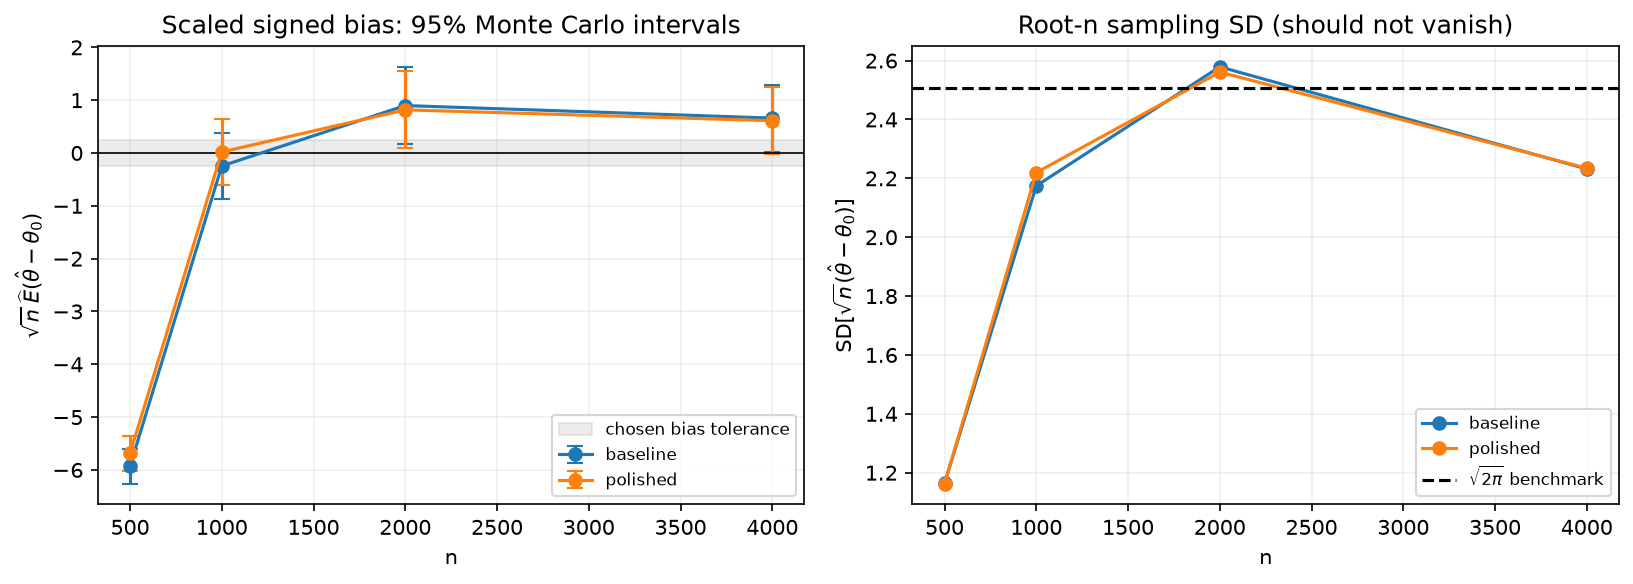

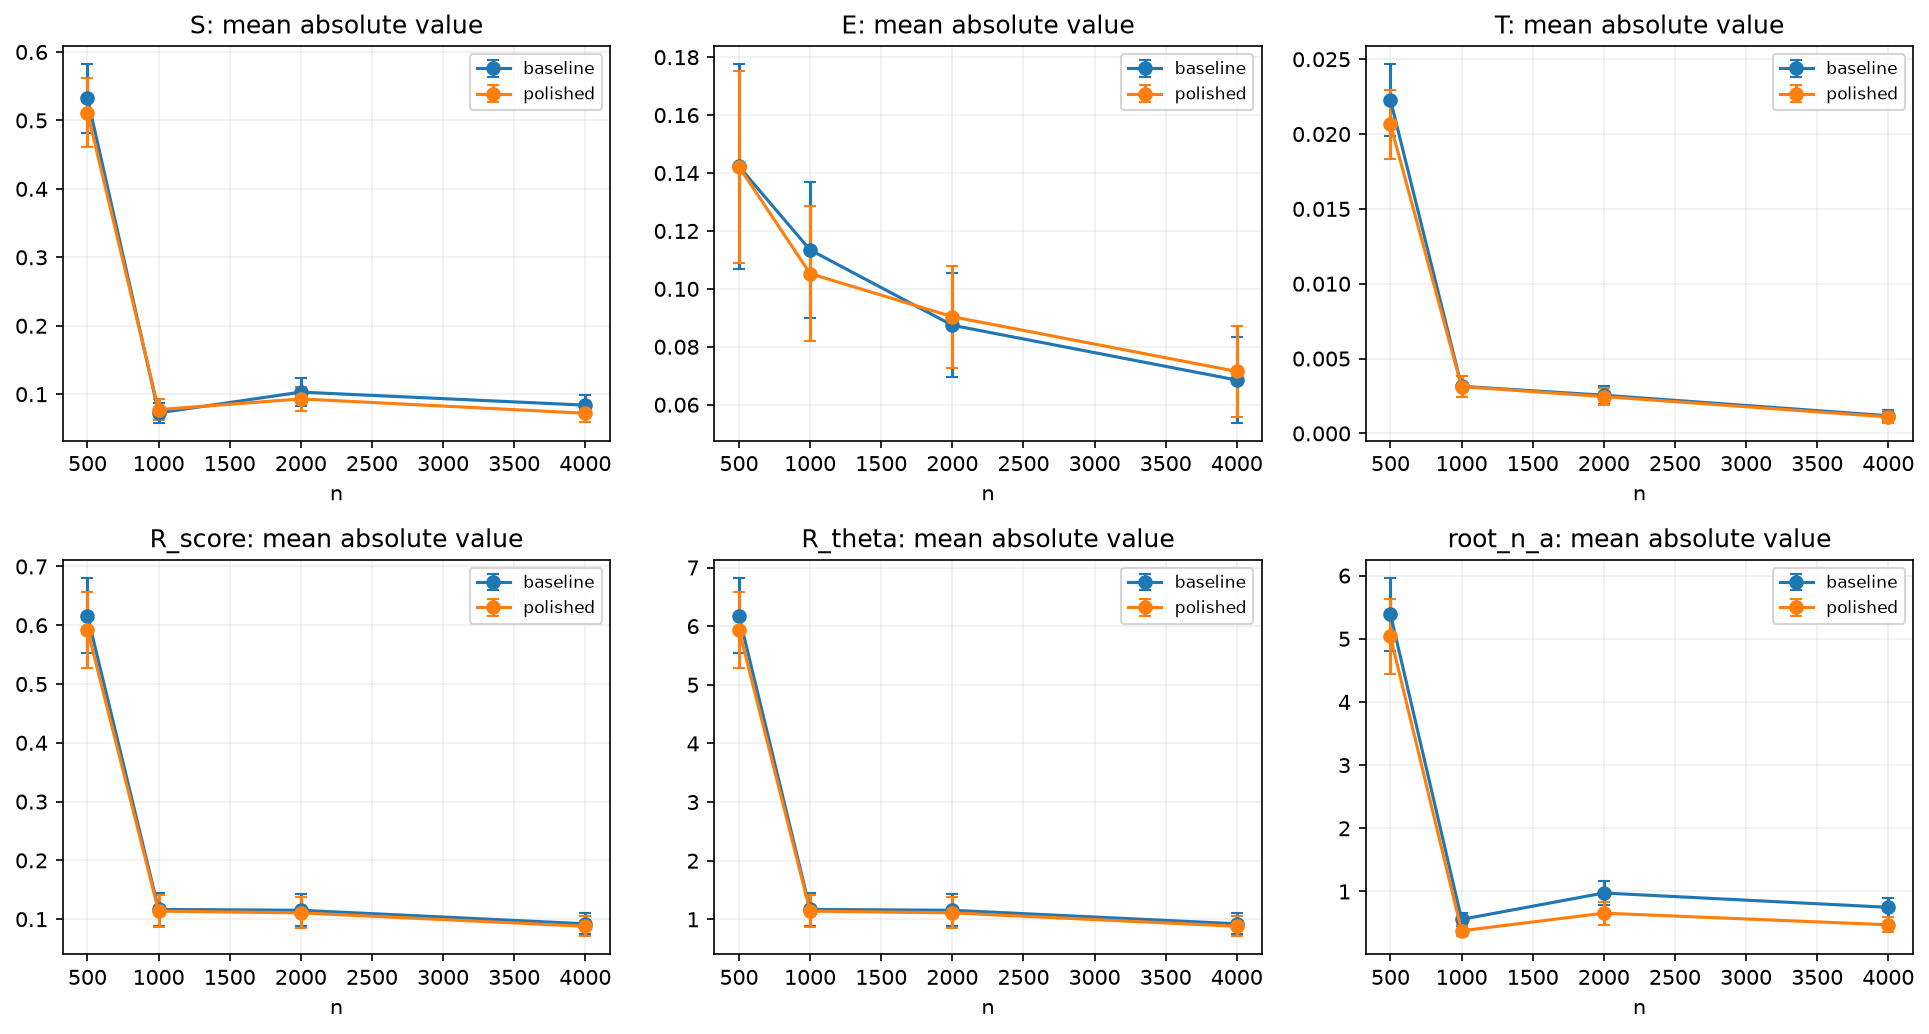

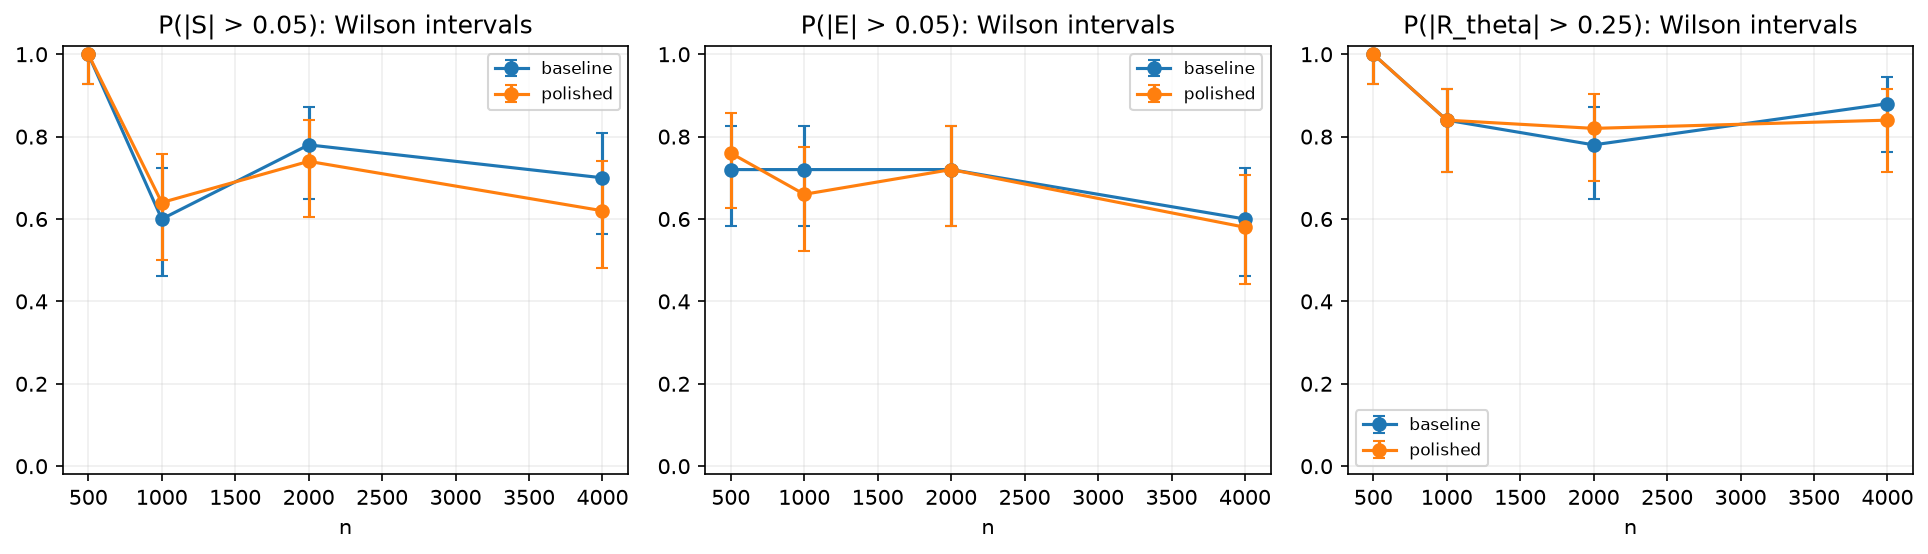

In [6]:
if tables:
    for path in diag.plot_diagnostics(tables, CONFIG, RUN_DIR):
        display(Image(filename=str(path)))


## Interpretation checks, without automatic convergence verdicts

1. **Numerical accuracy first:** inspect integration uncertainty before interpreting `E` or `T`.
   An exactly reconstructed decomposition is necessary for implementation correctness, but is
   not a test of the asymptotic claim.
2. **Bias:** inspect the signed root-$n$ bias and its Monte Carlo interval. To resolve an effect
   of size $\eta$, the simulation standard error must be much smaller than $\eta$.
   Under the nominal root-$n$ SD $\sqrt{2\pi}$, a 95% interval half-width of 0.25 needs roughly
   $(1.96\sqrt{2\pi}/0.25)^2\approx387$ replications, not 30.
3. **Vanishing in probability:** for `S`, `E`, `T`, and the total residual, inspect
   $P(|A_n|>\varepsilon)$ for several fixed $\varepsilon>0$, with Wilson intervals.
   Zero observed exceedances in a small Monte Carlo sample is not a zero probability.
4. **Optimization versus statistical error:** if polishing reduces `S` and the total residual,
   optimization error is implicated. If ordinary scores improve but projected scores do not,
   inspect the missing projection direction and network approximation. These patterns identify
   candidates for further checks, not definitive causal explanations.
5. **Sampling noise should remain:** `W`, root-$n$ sampling SD, scaled MAE, and scaled RMSE
   generally stay nonzero. Their failure to vanish does not contradict asymptotic normality.
6. **Limits of the experiment:** a finite grid cannot prove convergence. The Gaussian regressor
   remains outside the main theorem's compact-support assumption; the fixed network does not
   reproduce its growing class. Even the growing-width option does not enforce all bounds,
   sparsity, or approximation-rate assumptions. This tests the numerical estimator in the
   stated toy DGP, not the theorem under all its conditions.


In [7]:
if tables:
    integration = tables["integration"]
    print("Integration flags (rerun with more integration points if nonzero):",
          int(integration.inadequate_integrations.sum()))
    print("Maximum algebraic reconstruction error:", integration.max_decomposition_error.max())
    bias = tables["bias"].copy()
    tolerance = CONFIG["bias_tolerance"]
    bias["CI_inside_chosen_bias_band"] = (bias.ci_low > -tolerance) & (bias.ci_high < tolerance)
    print("Finite-sample bias assessment for tolerance", tolerance)
    display(bias[["n", "stage", "completed_reps", "root_n_bias", "ci_low", "ci_high",
                  "CI_inside_chosen_bias_band"]])
    print("No YES/NO conclusion about an asymptotic limit is inferred from these finite samples.")


Integration flags (rerun with more integration points if nonzero): 0
Maximum algebraic reconstruction error: 2.220446049250313e-16
Finite-sample bias assessment for tolerance 0.25


,n,stage,completed_reps,root_n_bias,ci_low,ci_high,CI_inside_chosen_bias_band
0,500,baseline,50,-5.927908,-6.258520,-5.597296,False
1,500,polished,50,-5.688238,-6.018772,-5.357704,False
2,1000,baseline,50,-0.245240,-0.863249,0.372769,False
3,1000,polished,50,0.019296,-0.611469,0.650061,False
4,2000,baseline,50,0.898216,0.165348,1.631085,False
5,2000,polished,50,0.817082,0.089271,1.544893,False
6,4000,baseline,50,0.660192,0.025926,1.294458,False
7,4000,polished,50,0.610404,-0.024575,1.245382,False


No YES/NO conclusion about an asymptotic limit is inferred from these finite samples.


## Reproducibility and sources

Every new run is keyed by its full configuration, helper-code hash, and Python/package versions.
Each replication saves baseline and polished model checkpoints plus both diagnostic rows;
only complete pairs are skipped on restart. Errors stop the run rather than silently dropping
failed fits. Summaries always report the number of completed replications.
Changing the configuration or helper code creates a separate run directory.
Do not run two writers against the same run directory concurrently.

New outputs: `replication_results.csv`, `bias_summary.csv`, `terms_summary.csv`,
`tails_summary.csv`, `integration_summary.csv`, `paired_summary.csv`, three figures,
and per-replication `.pt` model checkpoints and `result.json` files.
The old `run/` folder is never used for new training or new summary writes.

Sources: [Zhong and Wang, main paper](../../Zhong%20and%20Wang%202024%20JBES.pdf),
Section 3 and Theorem 3.3; [supplement](../../Zhong%20and%20Wang%202024%20JBES%20supplement.pdf),
pp. 4–6. The Gaussian population-score formula is derived here from the stated DGP
and the explicitly displayed score normalization.
